# Traffic Control System

1. The Traffic Vector ($X$)
We represent the real-time number of waiting cars at the 4 intersections as a $4 \times 1$ column vector:
$$ X = \begin{bmatrix} A \\ B \\ C \\ D \end{bmatrix} = \begin{bmatrix} North \\ South \\ East \\ West \end{bmatrix} $$

2. The Decision Algorithm ($W \times X$)
To determine which traffic light should turn green, we use a $2 \times 4$ Weight Matrix ($W$).
$$ W = \begin{bmatrix} 1 & 1 & 0 & 0 \\ 0 & 0 & 1 & 1 \end{bmatrix} $$

When we multiply $W \times X$, the Linear Algebra automatically isolates and sums the opposing directions, resulting in a $2 \times 1$ Priority Vector:
$$ Priority = \begin{bmatrix} Total_{NS} \\ Total_{EW} \end{bmatrix} $$

The system reads this vector and assigns the green light to the highest value.

3. The Clearance Action ($X_{new} = X - \alpha (G \times X)$)
Once a direction is chosen, we apply a Green Light Matrix ($G$). This acts as a projection matrix.
For example, if East/West wins, the matrix is:
$$ G_{EW} = \begin{bmatrix} 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} $$

By multiplying $G_{EW} \times X$, the matrix operations naturally zero out the North/South traffic (which have red lights) and isolate the East/West traffic. We then subtract a percentage of this resulting vector ($\alpha$) from the original traffic vector to simulate the cars driving through the intersection.

In [1]:
import numpy as np

# 1. Traffic State Vector: [A (North), B (South), C (East), D (West)]
X = np.array([12, 15, 40, 35]) 

# 2. Phase Weight Matrix (2x4)
# Row 0 checks North + South. Row 1 checks East + West.
W = np.array([
    [1, 1, 0, 0], 
    [0, 0, 1, 1]  
])

# 3. Green Light (Clearance) Matrices (4x4)
G_NS = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
])

G_EW = np.array([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

def traffic_light_algorithm(traffic_vector):
    print(f"Initial Traffic: North={traffic_vector[0]}, South={traffic_vector[1]}, East={traffic_vector[2]}, West={traffic_vector[3]}")
    
    # ALGORITHM STEP 1: Calculate Priority using Matrix Multiplication
    priority = W @ traffic_vector
    print(f"Priority Vector: NS={priority[0]}, EW={priority[1]}")
    
    # ALGORITHM STEP 2: Determine the winner
    if priority[0] >= priority[1]:
        print(" Decision: NORTH/SOUTH gets the Green Light!")
        G_active = G_NS
    else:
        print("Decision: EAST/WEST gets the Green Light!")
        G_active = G_EW

    # ALGORITHM STEP 3: Update traffic using Matrix Subtraction and Multiplication
    # Formula: X_new = X_old - (Green_Light * X_old)
    # Note: We multiply G_active by 0.8 assuming 80% of cars clear the intersection during the green light.
    traffic_vector = traffic_vector - (0.8 * (G_active @ traffic_vector))
    
    print(f"\nFinal Traffic remaining: {np.round(traffic_vector, 1)}")
    return traffic_vector

# Run the algorithm once
new_X = traffic_light_algorithm(X)


Initial Traffic: North=12, South=15, East=40, West=35
Priority Vector: NS=27, EW=75
Decision: EAST/WEST gets the Green Light!

Final Traffic remaining: [12. 15.  8.  7.]



--- Starting Traffic Simulation ---
Initial Traffic: North=50.0, South=45.0, East=30.0, West=25.0
Priority Vector: NS=95.0, EW=55.0
 Decision: NORTH/SOUTH gets the Green Light!

Final Traffic remaining: [10.  9. 30. 25.]
Initial Traffic: North=21.0, South=11.0, East=40.0, West=29.0
Priority Vector: NS=32.0, EW=69.0
Decision: EAST/WEST gets the Green Light!

Final Traffic remaining: [21.  11.   8.   5.8]
Initial Traffic: North=32.0, South=14.0, East=12.0, West=8.799999999999997
Priority Vector: NS=46.0, EW=20.799999999999997
 Decision: NORTH/SOUTH gets the Green Light!

Final Traffic remaining: [ 6.4  2.8 12.   8.8]
Initial Traffic: North=14.399999999999999, South=12.799999999999999, East=16.0, West=11.799999999999997
Priority Vector: NS=27.199999999999996, EW=27.799999999999997
Decision: EAST/WEST gets the Green Light!

Final Traffic remaining: [14.4 12.8  3.2  2.4]
Initial Traffic: North=18.4, South=18.799999999999997, East=11.2, West=7.359999999999999
Priority Vector: NS=37.19999999

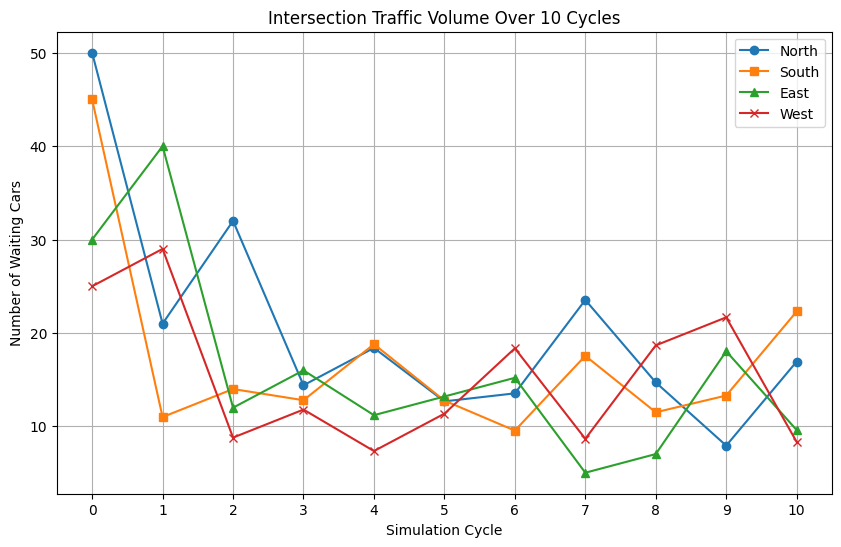

In [3]:
import matplotlib.pyplot as plt

# Simulating traffic control over multiple cycles with visualization
print("\n--- Starting Traffic Simulation ---")

# Let's start with a new traffic vector and simulate 10 cycles of traffic lights
sim_traffic = np.array([50.0, 45.0, 30.0, 25.0])

# Lists to store data for plotting
history_north = [sim_traffic[0]]
history_south = [sim_traffic[1]]
history_east = [sim_traffic[2]]
history_west = [sim_traffic[3]]
cycles = [0]

for cycle in range(1, 11):
    sim_traffic = traffic_light_algorithm(sim_traffic)
    
    # Simulate new cars arriving at each intersection during the cycle
    new_arrivals = np.random.randint(2, 12, size=4)
    sim_traffic += new_arrivals
    
    # Record history
    history_north.append(sim_traffic[0])
    history_south.append(sim_traffic[1])
    history_east.append(sim_traffic[2])
    history_west.append(sim_traffic[3])
    cycles.append(cycle)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(cycles, history_north, label='North', marker='o')
plt.plot(cycles, history_south, label='South', marker='s')
plt.plot(cycles, history_east, label='East', marker='^')
plt.plot(cycles, history_west, label='West', marker='x')

plt.title('Intersection Traffic Volume Over 10 Cycles')
plt.xlabel('Simulation Cycle')
plt.ylabel('Number of Waiting Cars')
plt.legend()
plt.grid(True)
plt.xticks(cycles)
plt.show()